In [1]:
!pip install networkx

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import yfinance as yf

In [25]:
var1 = yf.Ticker('MSFT')
microsoft = var1.institutional_holders
microsoft['comp'] = var1.ticker

In [27]:
var2 = yf.Ticker('AAPL')
apple = var2.institutional_holders
apple['comp'] = var2.ticker

In [29]:
together = pd.concat([apple,microsoft])
together

,Date Reported,Holder,pctHeld,Shares,Value,pctChange,comp
0,2025-12-31,Vanguard Group Inc,0.0972,1426283914,364814897781,0.0192,AAPL
1,2025-12-31,Blackrock Inc.,0.0786,1154665731,295340399265,0.0073,AAPL
2,2025-09-30,State Street Corporation,0.0407,597501113,152828833953,-0.0062,AAPL
3,2025-12-31,"Geode Capital Management, LLC",0.0244,358032517,91577556761,0.0052,AAPL
4,2025-09-30,"FMR, LLC",0.0207,303254081,77566328467,-0.0114,AAPL
5,2025-09-30,"Berkshire Hathaway, Inc",0.0162,238212764,60930060485,-0.1492,AAPL
6,2025-09-30,Morgan Stanley,0.0156,229103384,58600063279,-0.0176,AAPL
7,2025-12-31,JPMORGAN CHASE & CO,0.0154,225419111,57657699936,-0.5237,AAPL
8,2025-09-30,Price (T.Rowe) Associates Inc,0.0145,212755053,54418487196,0.0495,AAPL
9,2025-12-31,NORGES BANK,0.0131,192255086,49175005662,0.0129,AAPL


In [35]:
Graph = nx.from_pandas_edgelist(together, 'Holder', 'comp')

In [68]:
colors = []
for node in Graph:
    if node in together['comp'].values:
        colors.append('grey')
    else:
        colors.append('blue')

In [70]:
Graph.degree()

DegreeView({'Vanguard Group Inc': 2, 'AAPL': 10, 'Blackrock Inc.': 2, 'State Street Corporation': 2, 'Geode Capital Management, LLC': 2, 'FMR, LLC': 2, 'Berkshire Hathaway, Inc': 1, 'Morgan Stanley': 2, 'JPMORGAN CHASE & CO': 2, 'Price (T.Rowe) Associates Inc': 2, 'NORGES BANK': 2, 'MSFT': 10, 'Capital International Investors': 1})

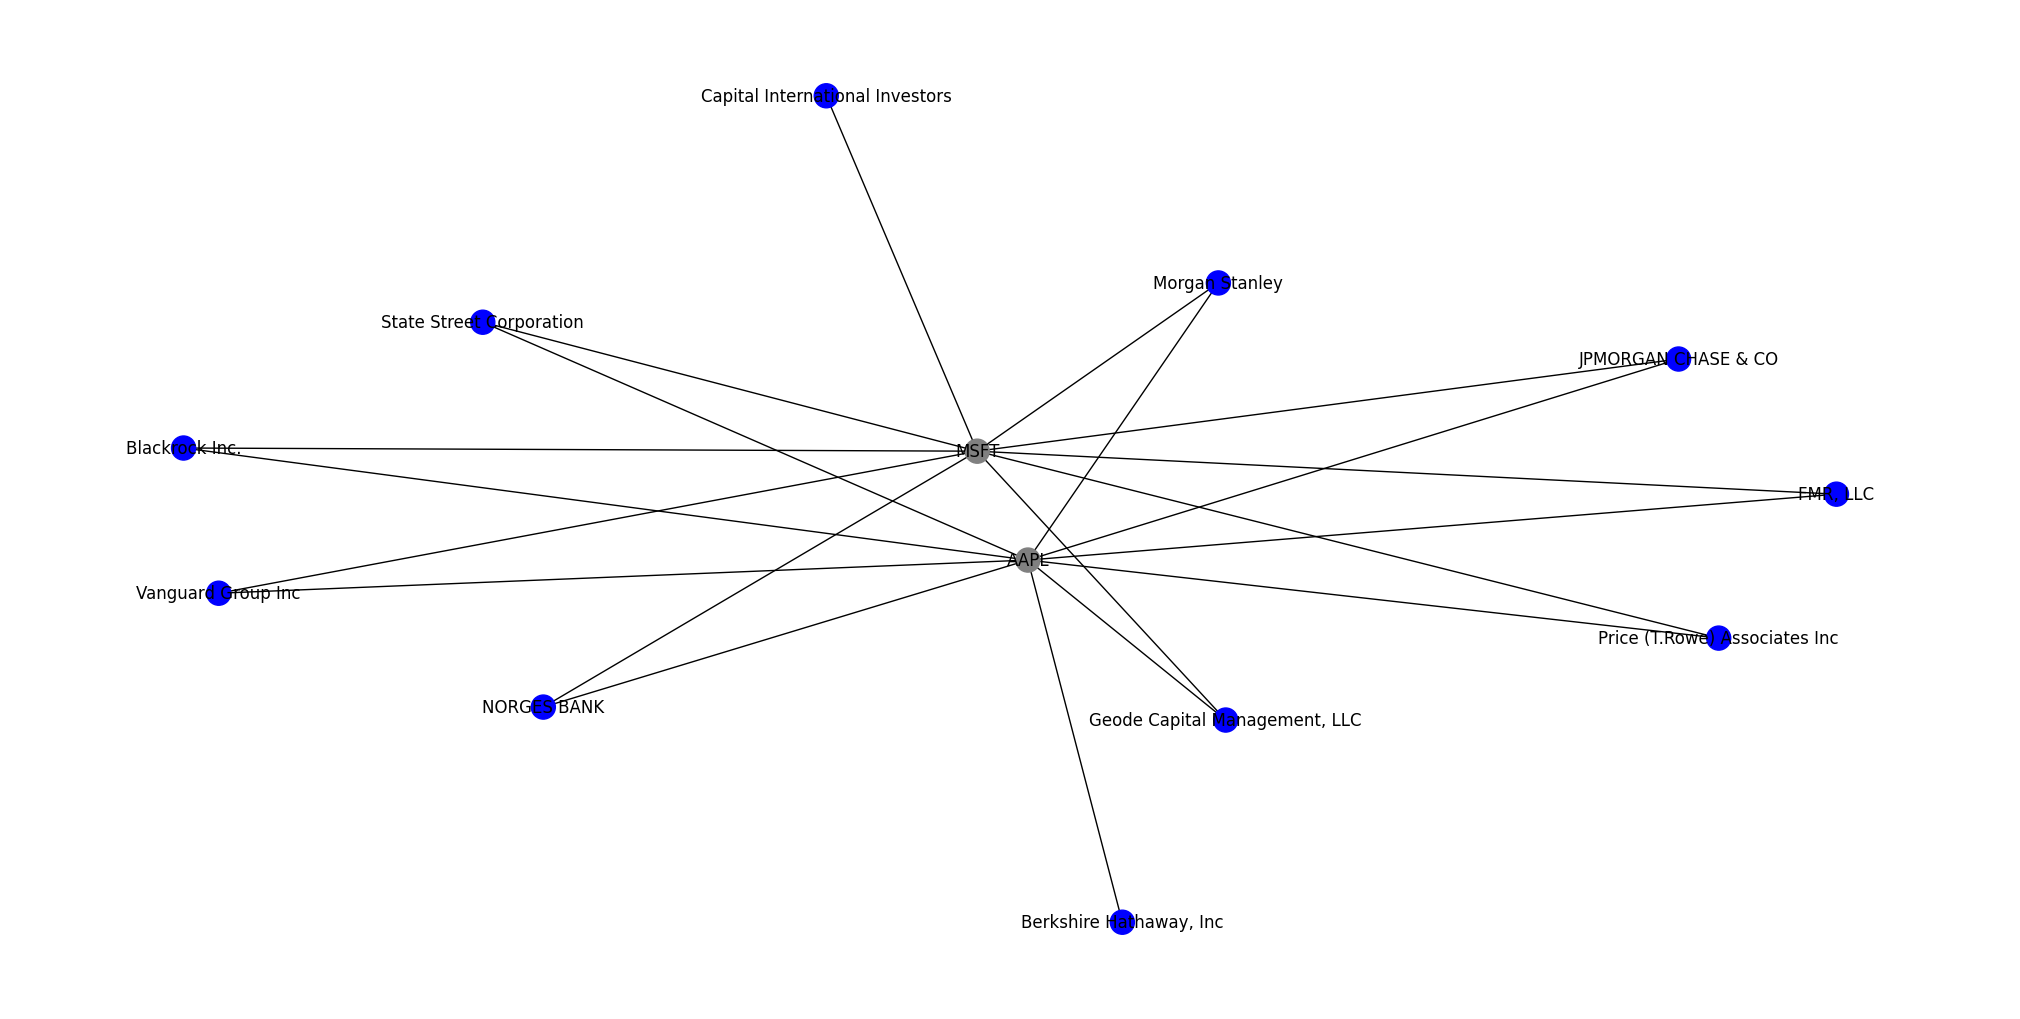

In [74]:
plt.figure(figsize=(20,10))
nx.draw(Graph, with_labels=True,
       node_color=colors)